<a href="https://colab.research.google.com/github/0zdata04/Myacount-/blob/main/promedio_Noruega_vs_Inglaterra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analisis_Noruega_Inglaterra.ipynb

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Objetivo del proyecto

Analizar el partido entre Noruega e Inglaterra utilizando datos previos al encuentro para identificar tendencias en el rendimiento de ambos equipos.

A partir de la información recopilada, se realizará un análisis exploratorio con Python y Pandas para comparar variables como victorias, empates, derrotas, goles a favor y goles en contra. Finalmente, se elaborará una predicción del resultado del partido basada en los datos y, una vez finalizado el encuentro, se compararán las predicciones con el resultado real para evaluar la precisión del análisis.

##Recolección de datos (FotMob)

Los datos utilizados en este análisis fueron recopilados manualmente desde la plataforma FotMob antes del inicio del partido entre Noruega e Inglaterra.

Se registró la siguiente información de cada equipo:

- Resultados de los últimos cinco partidos.
- Número de victorias, empates y derrotas.
- Goles a favor.
- Goles en contra.

Estos datos se utilizarán para construir un DataFrame en Pandas y realizar un análisis exploratorio que permita comparar el rendimiento reciente de ambos equipos y elaborar una predicción del partido.

Preguntas que responde

- ¿Cuántos córners puede haber?
- ¿Cuántas tarjetas?
- ¿Cuántos goles?
- ¿Qué equipo tiene más probabilidad de ganar?

Este análisis no es un modelo predictivo. Es un análisis descriptivo basado en los últimos cinco partidos. Las predicciones de goles, córners y tarjetas son estimaciones derivadas de esos promedios, no una garantía del resultado. Esa aclaración le da más rigor al trabajo y demuestra que sabes interpretar correctamente los datos.

#Creacion del DataFrame

In [87]:
datos_resumen ={
  "Equipo": ["Noruega","Inglaterra"],
  "Victorias": [4,4],
  "Empates":[0,1],
  "Derrotas":[1,0],
  "Goles_a_favor":[12,11],
  "Goles_en_contra":[9,5]
  }

df_resumen = pd.DataFrame(datos_resumen)

In [88]:
df_resumen

,Equipo,Victorias,Empates,Derrotas,Goles_a_favor,Goles_en_contra
0,Noruega,4,0,1,12,9
1,Inglaterra,4,1,0,11,5


Noruega presenta un mejor rendimiento ofensivo, con un promedio de 2.4 goles por partido. Por otro lado, Inglaterra destaca por su solidez defensiva, ya que solo recibe 1.0 gol por partido en promedio. Esto sugiere que el partido enfrentará dos estilos distintos: un equipo con mayor capacidad ofensiva contra otro con una defensa más consistente.

In [89]:
df_resumen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Equipo           2 non-null      object
 1   Victorias        2 non-null      int64 
 2   Empates          2 non-null      int64 
 3   Derrotas         2 non-null      int64 
 4   Goles_a_favor    2 non-null      int64 
 5   Goles_en_contra  2 non-null      int64 
dtypes: int64(5), object(1)
memory usage: 228.0+ bytes


Se verificó la estructura del DataFrame, confirmando el tipo de dato de cada columna y comprobando que no existen valores nulos.

In [90]:
df_resumen.describe()

,Victorias,Empates,Derrotas,Goles_a_favor,Goles_en_contra
count,2.0,2.000000,2.000000,2.000000,2.000000
mean,4.0,0.500000,0.500000,11.500000,7.000000
std,0.0,0.707107,0.707107,0.707107,2.828427
min,4.0,0.000000,0.000000,11.000000,5.000000
25%,4.0,0.250000,0.250000,11.250000,6.000000
50%,4.0,0.500000,0.500000,11.500000,7.000000
75%,4.0,0.750000,0.750000,11.750000,8.000000
max,4.0,1.000000,1.000000,12.000000,9.000000


Se calcularon estadísticas descriptivas para conocer el comportamiento general de las variables numéricas

##Variables calculadas

In [92]:
df_resumen["Promedio_GF"] = df_resumen["Goles_a_favor"] / 5


In [93]:
df_resumen["Promedio_GC"] = df_resumen["Goles_en_contra"] / 5

In [94]:
df_resumen["Diferencia_Goles"] = df_resumen["Goles_a_favor"] - df_resumen["Goles_en_contra"]

##Filtrar información

In [95]:
df_resumen.loc[df["Equipo"] == "Noruega","Goles_a_favor"]

,Goles_a_favor
0,12
1,11


Se aplicó un filtro para analizar únicamente la información correspondiente a Noruega.

##Ordenar

In [96]:
df_resumen.sort_values(by = "Diferencia_Goles", ascending=False)

,Equipo,Victorias,Empates,Derrotas,Goles_a_favor,Goles_en_contra,Promedio_GF,Promedio_GC,Diferencia_Goles
1,Inglaterra,4,1,0,11,5,2.2,1.0,6
0,Noruega,4,0,1,12,9,2.4,1.8,3


Se ordenaron los equipos según su diferencia de goles para identificar cuál presenta un mejor rendimiento global

##Segundo DataFrame

In [73]:
datos_partidos = {
    "Equipo": [
        "Noruega", "Noruega", "Noruega", "Noruega", "Noruega",
        "Inglaterra", "Inglaterra", "Inglaterra", "Inglaterra", "Inglaterra"
    ],
    "xG": [
        2.61, 1.49, 1.70, 2.20, 0.80,
        1.88, 2.16, 0.66, 1.36, 3.20
    ],
    "Tiros": [
        14, 14, 10, 13, 11,
        20, 16, 13, 19, 22
    ],
    "Tiros_arco": [
        4, 5, 4, 7, 1,
        5, 7, 2, 3, 11
    ],
    "Corners": [
        5, 14, 4, 5, 2,
        12, 5, 3, 9, 8
    ],
    "Amarillas": [
        1, 0, 1, 0, 1,
        2, 1, 2, 1, 0
    ]
}

In [75]:
df_partidos = pd.DataFrame(datos_partidos)

In [76]:
df_partidos

,Equipo,xG,Tiros,Tiros_arco,Corners,Amarillas
0,Noruega,2.61,14,4,5,1
1,Noruega,1.49,14,5,14,0
2,Noruega,1.70,10,4,4,1
3,Noruega,2.20,13,7,5,0
4,Noruega,0.80,11,1,2,1
5,Inglaterra,1.88,20,5,12,2
6,Inglaterra,2.16,16,7,5,1
7,Inglaterra,0.66,13,2,3,2
8,Inglaterra,1.36,19,3,9,1
9,Inglaterra,3.20,22,11,8,0


##grupar

In [77]:
df_partidos.groupby("Equipo").mean()

,xG,Tiros,Tiros_arco,Corners,Amarillas
Equipo,,,,,
Inglaterra,1.852,18.0,5.6,7.4,1.2
Noruega,1.760,12.4,4.2,6.0,0.6


Se agruparon los partidos por equipo para obtener el promedio de las estadísticas de los últimos cinco encuentros.

In [78]:
df.groupby("Equipo").sum()

,xG,Tiros,Tiros_arco,Corners,Amarillas
Equipo,,,,,
Inglaterra,9.26,90,28,37,6
Noruega,8.80,62,21,30,3


##Estadísticas


In [79]:
df.describe()

,xG,Tiros,Tiros_arco,Corners,Amarillas
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,1.80600,15.200000,4.900000,6.700000,0.900000
std,0.78252,3.966527,2.884826,3.945462,0.737865
min,0.66000,10.000000,1.000000,2.000000,0.000000
25%,1.39250,13.000000,3.250000,4.250000,0.250000
50%,1.79000,14.000000,4.500000,5.000000,1.000000
75%,2.19000,18.250000,6.500000,8.750000,1.000000
max,3.20000,22.000000,11.000000,14.000000,2.000000


##Ordenar

In [81]:
df.sort_values(by = "xG", ascending = False )

,Equipo,xG,Tiros,Tiros_arco,Corners,Amarillas
9,Inglaterra,3.20,22,11,8,0
0,Noruega,2.61,14,4,5,1
3,Noruega,2.20,13,7,5,0
6,Inglaterra,2.16,16,7,5,1
5,Inglaterra,1.88,20,5,12,2
2,Noruega,1.70,10,4,4,1
1,Noruega,1.49,14,5,14,0
8,Inglaterra,1.36,19,3,9,1
4,Noruega,0.80,11,1,2,1
7,Inglaterra,0.66,13,2,3,2


##Visualizaciones

Gráfico 1

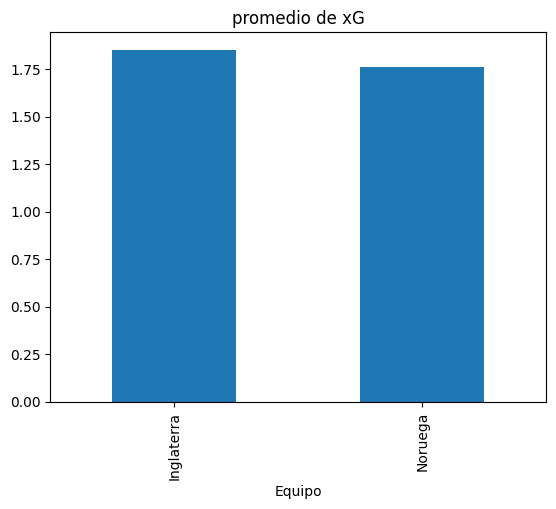

In [84]:
df_partidos.groupby("Equipo")["xG"].mean().plot(kind="bar")
plt.title("promedio de xG")
plt.show()

Gráfico 2

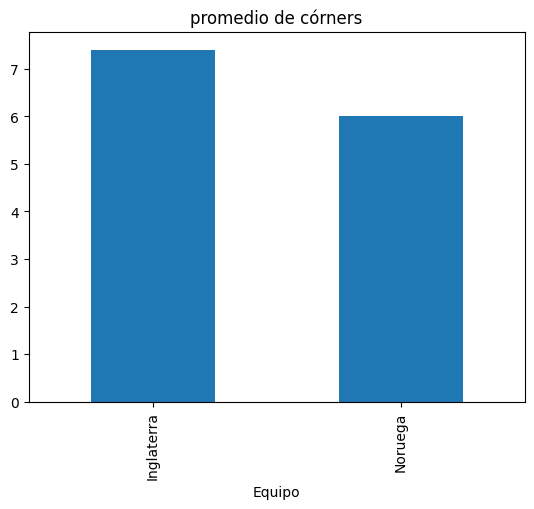

In [99]:
df_partidos.groupby("Equipo")["Corners"].mean().plot(kind="bar")
plt.title("promedio de córners")
plt.show()

Conclusión

A partir del análisis de los últimos cinco partidos de Noruega e Inglaterra, se observa que Inglaterra presenta mejores indicadores ofensivos, con un promedio superior de tiros, tiros a puerta, córners y un xG ligeramente mayor. Noruega, aunque registra menos volumen ofensivo, mantiene un rendimiento competitivo y ha demostrado capacidad para generar oportunidades de gol.

Con base en estas estadísticas, se espera un partido equilibrado, con una ligera ventaja para Inglaterra debido a su mayor producción ofensiva. Además, se estima que el encuentro tendrá entre 11 y 14 córners, 2 y 4 tarjetas amarillas y entre 2 y 4 goles, considerando el rendimiento reciente de ambos equipos.

Inglaterra genera más tiros.
Inglaterra tiene mayor promedio de córners.
Noruega mantiene un buen nivel ofensivo.
Se esperan entre 2 y 4 goles.
Se esperan entre 11 y 14 córners.
Se esperan entre 2 y 4 amarillas.
Inglaterra llega con una ligera ventaja estadística.